In [1]:
!pip install torch

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PinballNetwork(nn.Module):
    def __init__(self, num_bounces=5):
        super(PinballNetwork, self).__init__()
        self.num_bounces = num_bounces
        
        # تعریف ۳۰ نورون کل شبکه
        self.fc = nn.Linear(30, 30, bias=True)
        
        # ساخت ماتریس ماسک ۳۰ در ۳۰ با مقادیر ۱
        mask = torch.ones(30, 30)
        
        # اعمال قانون پینبال: قطع کردن اتصالات درون هر ضلع (مقدار صفر)
        # ضلع اول: نورون‌های 0 تا 9
        mask[0:10, 0:10] = 0
        # ضلع دوم: نورون‌های 10 تا 19
        mask[10:20, 10:20] = 0
        # ضلع سوم: نورون‌های 20 تا 29
        mask[20:30, 20:30] = 0
        
        # ثبت ماسک به عنوان یک بافر 
        # (بافرها مقادیری هستند که همراه مدل به GPU می‌روند اما توسط الگوریتم یادگیری آپدیت نمی‌شوند)
        self.register_buffer('mask', mask)

    def forward(self, x):
        # x می‌تواند ورودی‌هایی باشد که به هر کدام از ۳۰ نورون داده شده است
        # ابعاد x باید (batch_size, 30) باشد
        out = x
        
        for step in range(self.num_bounces):
            # در هر مرحله، وزن‌ها را در ماسک ضرب می‌کنیم تا دیواره‌های پینبال حفظ شوند
            # اتصالاتی که روی یک ضلع هستند ضرب در صفر شده و عملاً حذف می‌شوند
            masked_weight = self.fc.weight * self.mask
            
            # انجام محاسبات خطی و عبور از تابع فعال‌ساز ReLU
            out = F.linear(out, masked_weight, self.fc.bias)
            out = torch.relu(out)
            
        return out

# ---------- تست کـد ----------
if __name__ == "__main__":
    # ایجاد مدل با ۵ مرحله چرخش (برخورد پینبال)
    model = PinballNetwork(num_bounces=5)
    
    # تولید یک دیتای ورودی تصادفی برای تست (مثلاً یک بچ با اندازه 4)
    # ورودی همزمان به تمام ۳۰ نورون تزریق می‌شود
    dummy_input = torch.randn(4, 30)
    
    # اجرای مدل
    output = model(dummy_input)
    
    print("شکل دیتای ورودی:", dummy_input.shape)
    print("شکل دیتای خروجی:", output.shape)
    print("\nتعداد کل پارامترهای وزن:", model.fc.weight.numel())
    print("تعداد اتصالات فعال (غیر صفر) در ماسک:", int(model.mask.sum().item()))

شکل دیتای ورودی: torch.Size([4, 30])
شکل دیتای خروجی: torch.Size([4, 30])

تعداد کل پارامترهای وزن: 900
تعداد اتصالات فعال (غیر صفر) در ماسک: 600


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_moons

# ۱. تولید یک دیتاست مصنوعی و چالش‌برانگیز (دو هلال در هم تنیده)
X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

# ۲. نسخه کامل شبکه پینبال به عنوان یک طبقه‌بند (Classifier)
class PinballClassifier(nn.Module):
    def __init__(self, input_dim=2, num_classes=2, num_bounces=5):
        super().__init__()
        self.num_bounces = num_bounces
        
        # لایه ورودی: پرتاب توپ به داخل زمین ۳۰ نورونی
        self.entry = nn.Linear(input_dim, 30)
        
        # هسته پینبال (زمین بازی)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        
        # لایه خروجی: جمع‌آوری نتیجه از ۳۰ نورون و تبدیل به ۲ کلاس
        self.exit = nn.Linear(30, num_classes)

    def forward(self, x):
        # وارد شدن دیتا و فعال‌سازی اولیه
        out = torch.relu(self.entry(x))
        
        # چرخش دیتا درون شبکه (برخورد به دیواره‌ها)
        for step in range(self.num_bounces):
            masked_weight = self.core.weight * self.mask
            out = torch.relu(F.linear(out, masked_weight, self.core.bias))
            
        # خروج نهایی
        return self.exit(out)

# ۳. تنظیمات آموزش
model = PinballClassifier(input_dim=2, num_classes=2, num_bounces=5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ۴. حلقه آموزش (Training Loop)
print("شروع آموزش شبکه پینبال...\n")
for epoch in range(150):
    optimizer.zero_grad()     # صفر کردن گرادیان‌های قبلی
    outputs = model(X)        # حدس زدن خروجی
    loss = criterion(outputs, y) # محاسبه میزان خطا
    loss.backward()           # محاسبه مسیر اصلاح (Backpropagation)
    optimizer.step()          # آپدیت کردن وزن‌ها
    
    # گزارش‌گیری هر 30 ایپاک
    if (epoch+1) % 30 == 0:
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y).sum().item() / y.size(0) * 100
        print(f"مرحله {epoch+1:3d} | میزان خطا (Loss): {loss.item():.4f} | دقت مدل: {accuracy:.1f}%")

شروع آموزش شبکه پینبال...

مرحله  30 | میزان خطا (Loss): 0.2506 | دقت مدل: 88.7%
مرحله  60 | میزان خطا (Loss): 0.0700 | دقت مدل: 97.4%
مرحله  90 | میزان خطا (Loss): 0.0564 | دقت مدل: 97.8%
مرحله 120 | میزان خطا (Loss): 0.0530 | دقت مدل: 98.3%
مرحله 150 | میزان خطا (Loss): 0.0533 | دقت مدل: 98.0%


## VS Fully connected MLP

در حال آموزش هر دو مدل... لطفاً صبر کنید.

دقت نهایی مدل پینبال: 99.0%
دقت نهایی مدل استاندارد (MLP): 99.0%


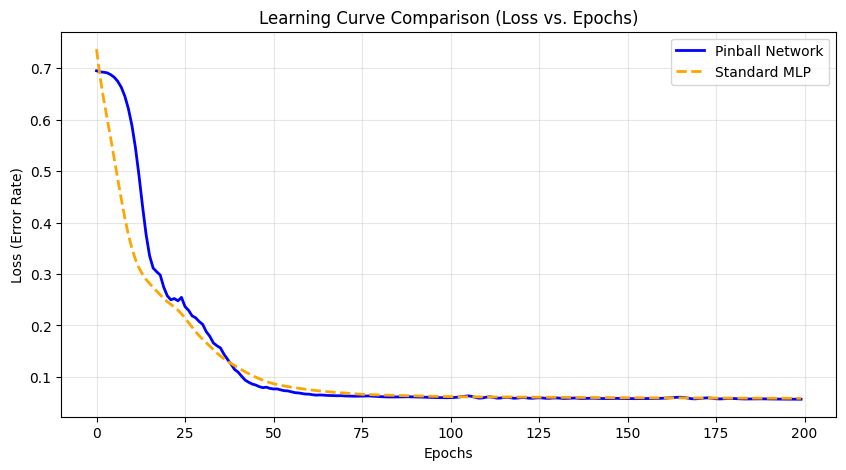

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. آماده‌سازی دیتاست
X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. مدل اول: شبکه پینبال (ایده شما)
class PinballClassifier(nn.Module):
    def __init__(self, input_dim=2, num_classes=2, num_bounces=5):
        super().__init__()
        self.num_bounces = num_bounces
        self.entry = nn.Linear(input_dim, 30)
        
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(30, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        for _ in range(self.num_bounces):
            masked_weight = self.core.weight * self.mask
            out = torch.relu(F.linear(out, masked_weight, self.core.bias))
        return self.exit(out)

# ۳. مدل دوم: شبکه استاندارد (Standard MLP)
class StandardMLP(nn.Module):
    def __init__(self, input_dim=2, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ۴. تنظیمات آموزش برای هر دو مدل
epochs = 200
model_pinball = PinballClassifier()
model_mlp = StandardMLP()

opt_pinball = optim.Adam(model_pinball.parameters(), lr=0.01)
opt_mlp = optim.Adam(model_mlp.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

history_pinball = []
history_mlp = []

# ۵. حلقه آموزش همزمان
print("در حال آموزش هر دو مدل... لطفاً صبر کنید.\n")
for epoch in range(epochs):
    # آموزش پینبال
    opt_pinball.zero_grad()
    out_p = model_pinball(X_train)
    loss_p = criterion(out_p, y_train)
    loss_p.backward()
    opt_pinball.step()
    history_pinball.append(loss_p.item())
    
    # آموزش MLP استاندارد
    opt_mlp.zero_grad()
    out_m = model_mlp(X_train)
    loss_m = criterion(out_m, y_train)
    loss_m.backward()
    opt_mlp.step()
    history_mlp.append(loss_m.item())

# ارزیابی نهایی روی دیتای تست
with torch.no_grad():
    acc_p = (model_pinball(X_test).argmax(1) == y_test).float().mean().item() * 100
    acc_m = (model_mlp(X_test).argmax(1) == y_test).float().mean().item() * 100

print(f"دقت نهایی مدل پینبال: {acc_p:.1f}%")
print(f"دقت نهایی مدل استاندارد (MLP): {acc_m:.1f}%")

# ۶. رسم نمودار مقایسه
plt.figure(figsize=(10, 5))
plt.plot(history_pinball, label=f'Pinball Network', color='blue', linewidth=2)
plt.plot(history_mlp, label=f'Standard MLP', color='orange', linewidth=2, linestyle='--')
plt.title('Learning Curve Comparison (Loss vs. Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## testing on images

In [5]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ۱. بارگذاری و آماده‌سازی دیتاست تصاویر ارقام (8x8)
digits = load_digits()
X_np, y_np = digits.data, digits.target # X_np شامل بردار ۶۴ تایی برای هر تصویر است

X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری شبکه پینبال برای تصاویر (خروجی ۱۰ کلاسی)
class PinballImageClassifier(nn.Module):
    def __init__(self, input_dim=64, num_classes=10, num_bounces=5):
        super().__init__()
        self.num_bounces = num_bounces
        self.entry = nn.Linear(input_dim, 30) # تبدیل ۶۴ پیکسل به ۳۰ نورون هسته
        
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(30, num_classes) # تبدیل ۳۰ نورون به ۱۰ کلاس خروجی

    def forward(self, x):
        out = torch.relu(self.entry(x))
        for _ in range(self.num_bounces):
            masked_weight = self.core.weight * self.mask
            out = torch.relu(F.linear(out, masked_weight, self.core.bias))
        return self.exit(out)

# ۳. معماری شبکه استاندارد MLP با تعداد پارامترهای مشابه
class StandardImageMLP(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ۴. فرآیند سنجش زمان و آموزش مدل‌ها
epochs = 300
criterion = nn.CrossEntropyLoss()

# --- آموزش و زمان‌بندی مدل پینبال ---
model_pinball = PinballImageClassifier()
opt_pinball = optim.Adam(model_pinball.parameters(), lr=0.005)

start_time = time.time()
for epoch in range(epochs):
    opt_pinball.zero_grad()
    outputs = model_pinball(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_pinball.step()
pinball_train_time = time.time() - start_time

# --- آموزش و زمان‌بندی مدل استاندارد MLP ---
model_mlp = StandardImageMLP()
opt_mlp = optim.Adam(model_mlp.parameters(), lr=0.005)

start_time = time.time()
for epoch in range(epochs):
    opt_mlp.zero_grad()
    outputs = model_mlp(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_mlp.step()
mlp_train_time = time.time() - start_time

# ۵. تست مدل‌ها و محاسبه زمان استنتاج (Inference Time)
start_time = time.time()
with torch.no_grad():
    pred_p = model_pinball(X_test)
    acc_p = (pred_p.argmax(1) == y_test).float().mean().item() * 100
pinball_inf_time = (time.time() - start_time) * 1000 # تبدیل به میلی‌ثانیه

start_time = time.time()
with torch.no_grad():
    pred_m = model_mlp(X_test)
    acc_m = (pred_m.argmax(1) == y_test).float().mean().item() * 100
mlp_inf_time = (time.time() - start_time) * 1000 # تبدیل به میلی‌ثانیه

# ۶. چاپ نتایج نهایی نبرد مدل‌ها
print(f"{'معیار سنجش':<30} | {'شبکه پینبال (ایده شما)':<25} | {'شبکه استاندارد MLP':<20}")
print("-" * 85)
print(f"{'دقت روی تصاویر تست':<30} | {acc_p:.2f}%{'':<20} | {acc_m:.2f}%")
print(f"{'زمان آموزش (۳۰۰ ایپاک)':<30} | {pinball_train_time:.4f} ثانیه{'':<14} | {mlp_train_time:.4f} ثانیه")
print(f"{'زمان پاسخ‌دهی به کل تست‌ها':<30} | {pinball_inf_time:.4f} میلی‌ثانیه{'':<11} | {mlp_inf_time:.4f} میلی‌ثانیه")

معیار سنجش                     | شبکه پینبال (ایده شما)    | شبکه استاندارد MLP  
-------------------------------------------------------------------------------------
دقت روی تصاویر تست             | 93.89%                     | 97.22%
زمان آموزش (۳۰۰ ایپاک)         | 0.5908 ثانیه               | 0.3204 ثانیه
زمان پاسخ‌دهی به کل تست‌ها     | 1.1132 میلی‌ثانیه            | 0.4225 میلی‌ثانیه


## without the for loop

In [15]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ۱. بارگذاری دیتاست
digits = load_digits()
X_np, y_np = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. شبکه پینبال بهینه‌شده (بدون حلقه For)
class PinballUnrolled(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.entry = nn.Linear(input_dim, 30)
        self.core = nn.Linear(30, 30)
        
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(30, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        
        # ترفند بهینه‌سازی: اعمال ماسک فقط یک بار انجام می‌شود
        masked_weight = self.core.weight * self.mask
        bias = self.core.bias
        
        # باز کردن حلقه (Loop Unrolling) برای ۵ مرحله
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        
        return self.exit(out)

# ۳. معماری شبکه استاندارد MLP
class StandardImageMLP(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ۴. تنظیمات آموزش
epochs = 300
criterion = nn.CrossEntropyLoss()

# --- آموزش مدل پینبال بهینه‌شده ---
model_pinball = PinballUnrolled()
opt_pinball = optim.Adam(model_pinball.parameters(), lr=0.005)

start_time = time.time()
for epoch in range(epochs):
    opt_pinball.zero_grad()
    outputs = model_pinball(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_pinball.step()
pinball_train_time = time.time() - start_time

# --- آموزش مدل استاندارد MLP ---
model_mlp = StandardImageMLP()
opt_mlp = optim.Adam(model_mlp.parameters(), lr=0.005)

start_time = time.time()
for epoch in range(epochs):
    opt_mlp.zero_grad()
    outputs = model_mlp(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_mlp.step()
mlp_train_time = time.time() - start_time

# ۵. تست مدل‌ها و محاسبه زمان استنتاج
start_time = time.time()
with torch.no_grad():
    pred_p = model_pinball(X_test)
    acc_p = (pred_p.argmax(1) == y_test).float().mean().item() * 100
pinball_inf_time = (time.time() - start_time) * 1000 

start_time = time.time()
with torch.no_grad():
    pred_m = model_mlp(X_test)
    acc_m = (pred_m.argmax(1) == y_test).float().mean().item() * 100
mlp_inf_time = (time.time() - start_time) * 1000 

# ۶. نمایش نتایج
print(f"{'معیار سنجش':<30} | {'پینبال بهینه‌شده':<20} | {'استاندارد MLP':<20}")
print("-" * 75)
print(f"{'دقت روی تصاویر تست':<30} | {acc_p:.2f}%{'':<14} | {acc_m:.2f}%")
print(f"{'زمان آموزش (۳۰۰ ایپاک)':<30} | {pinball_train_time:.4f} ثانیه{'':<8} | {mlp_train_time:.4f} ثانیه")
print(f"{'زمان استنتاج (تست)':<30} | {pinball_inf_time:.4f} میلی‌ثانیه{'':<5} | {mlp_inf_time:.4f} میلی‌ثانیه")

معیار سنجش                     | پینبال بهینه‌شده     | استاندارد MLP       
---------------------------------------------------------------------------
دقت روی تصاویر تست             | 95.00%               | 97.22%
زمان آموزش (۳۰۰ ایپاک)         | 0.8283 ثانیه         | 0.3744 ثانیه
زمان استنتاج (تست)             | 0.6568 میلی‌ثانیه      | 0.7501 میلی‌ثانیه


In [9]:
import time
import torch

# تنظیمات اولیه
features = 30
batch_size = 128
bounces = 5
runs = 1000

# دیتای ورودی فرضی (تنسور ترانهاده شده برای راحتی ضرب ماتریسی)
# ابعاد: (30, 128)
x = torch.randn(features, batch_size)

print("در حال آماده‌سازی ماتریس‌ها...\n")

# ==========================================
# ۱. ساخت مدل متراکم (Dense Masked) - روش قبلی
# ==========================================
dense_weight = torch.randn(features, features)
mask = torch.ones(features, features)
mask[0:10, 0:10] = 0
mask[10:20, 10:20] = 0
mask[20:30, 20:30] = 0
dense_masked_weight = dense_weight * mask  # صفرها اینجا حضور فیزیکی دارند!

# ==========================================
# ۲. ساخت مدل پراکنده واقعی (Sparse Tensor)
# ==========================================
# استخراج مختصاتِ (ایندکس‌های) ۶۰۰ اتصال مجاز
indices = torch.nonzero(mask).t()  # ابعاد: (2, 600)
# استخراج مقادیر وزن برای آن ۶۰۰ اتصال
values = dense_weight[mask == 1]   # ابعاد: (600,)

# ساخت تنسور اسپارس (بدون هیچ صفری در حافظه)
sparse_weight = torch.sparse_coo_tensor(indices, values, (features, features))

print("شروع تست سرعت (Inference)...\n")

# --- تست سرعت مدل متراکم ---
start_time = time.time()
for _ in range(runs):
    out = x
    for _ in range(bounces):
        # ضرب ماتریسی استاندارد
        out = torch.relu(torch.mm(dense_masked_weight, out))
dense_time = (time.time() - start_time) * 1000

# --- تست سرعت مدل پراکنده ---
start_time = time.time()
for _ in range(runs):
    out = x
    for _ in range(bounces):
        # ضرب ماتریسی مخصوص تنسورهای اسپارس
        out = torch.relu(torch.sparse.mm(sparse_weight, out))
sparse_time = (time.time() - start_time) * 1000

print(f"{'معیار (۱۰۰۰ اجرا)':<25} | {'زمان صرف شده'}")
print("-" * 45)
print(f"{'مدل متراکم (با ضرب صفرها)':<25} | {dense_time:.2f} میلی‌ثانیه")
print(f"{'مدل پراکنده (Sparse)':<25} | {sparse_time:.2f} میلی‌ثانیه")

در حال آماده‌سازی ماتریس‌ها...

شروع تست سرعت (Inference)...

معیار (۱۰۰۰ اجرا)         | زمان صرف شده
---------------------------------------------
مدل متراکم (با ضرب صفرها) | 43.86 میلی‌ثانیه
مدل پراکنده (Sparse)      | 435.14 میلی‌ثانیه


## Weights

In [11]:
import torch

# استخراج ماتریس‌ها از مدل آموزش‌دیده شما
weights_matrix = model_pinball.core.weight.data
mask_matrix = model_pinball.mask
biases_array = model_pinball.core.bias.data

# اضافه کردن encoding="utf-8" برای پشتیبانی از زبان فارسی
with open("pinball_weights.h", "w", encoding="utf-8") as f:
    f.write("// این فایل توسط اسکریپت پایتون تولید شده است\n")
    f.write("#ifndef PINBALL_WEIGHTS_H\n#define PINBALL_WEIGHTS_H\n\n")
    
    # ۱. استخراج ایندکس‌ها (آدرس نورون‌های مجاز)
    f.write("const int target_indices[30][20] = {\n")
    for i in range(30):
        # پیدا کردن 20 اتصالی که ماسک آن‌ها 1 است
        valid_indices = torch.nonzero(mask_matrix[i]).squeeze().tolist()
        f.write("    {" + ", ".join(map(str, valid_indices)) + "},\n")
    f.write("};\n\n")

    # ۲. استخراج مقادیر وزن‌ها
    f.write("const float weights[30][20] = {\n")
    for i in range(30):
        valid_indices = torch.nonzero(mask_matrix[i]).squeeze()
        valid_weights = weights_matrix[i][valid_indices].tolist()
        # ذخیره با 6 رقم اعشار
        f.write("    {" + ", ".join([f"{w:.6f}" for w in valid_weights]) + "},\n")
    f.write("};\n\n")

    # ۳. استخراج بایاس‌ها
    f.write("const float biases[30] = {\n")
    biases_list = biases_array.tolist()
    f.write("    " + ", ".join([f"{b:.6f}" for b in biases_list]) + "\n")
    f.write("};\n\n")

    f.write("#endif\n")

print("فایل pinball_weights.h با موفقیت ساخته شد! در پوشه فعلی شما قرار دارد.")

فایل pinball_weights.h با موفقیت ساخته شد! در پوشه فعلی شما قرار دارد.


## PinBall with Bumper

In [20]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ۱. بارگذاری دیتاست
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری جدید: پینبال با بامپر مرکزی (۳۱ نورون)
class PinballWithBumper(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        # دروازه ورودی حالا به جای 30 به 31 نورون شلیک می‌کند
        self.entry = nn.Linear(input_dim, 31)
        
        # هسته پینبال 31 در 31
        self.core = nn.Linear(31, 31)
        
        # ساخت ماسک 31 در 31
        mask = torch.ones(31, 31)
        
        # قوانین دیواره‌ها (نورون‌های هر ضلع به هم وصل نیستند)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        
        # قانون بامپر: نورون مرکزی (ایندکس 30) به خودش وصل نیست، اما به بقیه وصل است
        mask[30, 30] = 0 
        
        self.register_buffer('mask', mask)
        
        # دروازه خروج از 31 نورون
        self.exit = nn.Linear(31, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        
        masked_weight = self.core.weight * self.mask
        bias = self.core.bias
        
        # ۵ برخورد توپ به دیواره‌ها و بامپر مرکزی
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        
        return self.exit(out)

# ۳. آموزش و تست مدل جدید
model_bumper = PinballWithBumper()
opt_bumper = optim.Adam(model_bumper.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()
epochs = 300

print("در حال آموزش شبکه پینبال با بامپر مرکزی...\n")
start_time = time.time()
for epoch in range(epochs):
    opt_bumper.zero_grad()
    outputs = model_bumper(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_bumper.step()
train_time = time.time() - start_time

# محاسبه دقت و سرعت استنتاج
start_time = time.time()
with torch.no_grad():
    predictions = model_bumper(X_test)
    accuracy = (predictions.argmax(1) == y_test).float().mean().item() * 100
inf_time = (time.time() - start_time) * 1000

# ۴. نمایش نتایج
print(f"{'معیار سنجش':<30} | {'پینبال با بامپر (31 نورون)'}")
print("-" * 55)
print(f"{'دقت روی تصاویر تست':<30} | {accuracy:.2f}%")
print(f"{'زمان آموزش (۳۰۰ ایپاک)':<30} | {train_time:.4f} ثانیه")
print(f"{'زمان استنتاج (تست)':<30} | {inf_time:.4f} میلی‌ثانیه")

در حال آموزش شبکه پینبال با بامپر مرکزی...

معیار سنجش                     | پینبال با بامپر (31 نورون)
-------------------------------------------------------
دقت روی تصاویر تست             | 96.11%
زمان آموزش (۳۰۰ ایپاک)         | 0.6943 ثانیه
زمان استنتاج (تست)             | 0.4606 میلی‌ثانیه


## Validation with StratifiedKFold

In [21]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold

# ۱. بارگذاری کل دیتاست
digits = load_digits()
X_np = digits.data
y_np = digits.target

# تبدیل به تنسورهای پای‌تورچ
X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.long)

# ۲. معماری پینبال با بامپر مرکزی (۳۱ نورون)
class PinballWithBumper(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.entry = nn.Linear(input_dim, 31)
        self.core = nn.Linear(31, 31)
        
        mask = torch.ones(31, 31)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        mask[30, 30] = 0 # بامپر مرکزی به خودش وصل نیست
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(31, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        masked_weight = self.core.weight * self.mask
        bias = self.core.bias
        
        # باز کردن حلقه برای ۵ برخورد
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        
        return self.exit(out)

# ۳. تنظیمات Stratified K-Fold
k_folds = 5
# پارامتر shuffle=True باعث می‌شود عکس‌ها قبل از تکه‌تکه شدن به خوبی بر هم بخورند
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_accuracies = []
epochs = 200

print(f"شروع ارزیابی سخت‌گیرانه با {k_folds}-Fold Cross-Validation...\n")
start_time = time.time()

# ۴. حلقه اصلی برای چرخش بین تکه‌ها
for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    
    # جدا کردن دیتای آموزش و تست برای این مرحله
    X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
    X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

    # **نکته حیاتی:** مدل و بهینه‌ساز باید در هر مرحله از صفر ساخته شوند
    model = PinballWithBumper()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()

    # آموزش مدل روی ۴ تکه
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    # ارزیابی مدل روی تکه پنجم (دیتای کاملاً جدید)
    with torch.no_grad():
        predictions = model(X_test)
        accuracy = (predictions.argmax(1) == y_test).float().mean().item() * 100
        fold_accuracies.append(accuracy)

    print(f"پایان مرحله {fold+1} | دقت روی دیتای تستِ این تکه: {accuracy:.2f}%")

# ۵. گزارش آماری نهایی
total_time = time.time() - start_time
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\n" + "="*45)
print("             نتایج نهایی و قطعی")
print("="*45)
print(f"میانگین دقت کل (Mean Accuracy) : {mean_acc:.2f}%")
print(f"میزان نوسان (Standard Dev)     : ±{std_acc:.2f}%")
print(f"زمان کل اجرای تست              : {total_time:.2f} ثانیه")
print("="*45)

شروع ارزیابی سخت‌گیرانه با 5-Fold Cross-Validation...

پایان مرحله 1 | دقت روی دیتای تستِ این تکه: 94.17%
پایان مرحله 2 | دقت روی دیتای تستِ این تکه: 96.67%
پایان مرحله 3 | دقت روی دیتای تستِ این تکه: 93.04%
پایان مرحله 4 | دقت روی دیتای تستِ این تکه: 96.10%
پایان مرحله 5 | دقت روی دیتای تستِ این تکه: 96.10%

             نتایج نهایی و قطعی
میانگین دقت کل (Mean Accuracy) : 95.21%
میزان نوسان (Standard Dev)     : ±1.38%
زمان کل اجرای تست              : 2.36 ثانیه


## PinBall without Bumper validation with StratifiedKFold

In [22]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold

# ۱. بارگذاری دیتاست
digits = load_digits()
X_np = digits.data
y_np = digits.target

X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.long)

# ۲. معماری شبکه پینبال اصلی (۳۰ نورون - بدون بامپر)
class PinballOriginal(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.entry = nn.Linear(input_dim, 30)
        self.core = nn.Linear(30, 30)
        
        # ماسک اصلی: فقط اتصالات روی یک ضلع قطع هستند
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(30, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        masked_weight = self.core.weight * self.mask
        bias = self.core.bias
        
        # ۵ برخورد بدون هیچ واسطه‌ای در مرکز
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        
        return self.exit(out)

# ۳. تنظیمات Stratified K-Fold (دقیقاً مشابه تست قبلی)
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_accuracies = []
epochs = 200

print(f"شروع ارزیابی شبکه پینبال اصلی (۳۰ نورون - بدون بامپر)...\n")
start_time = time.time()

# ۴. حلقه ارزیابی
for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
    X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

    # ساخت مدل تازه برای هر تکه
    model = PinballOriginal()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        predictions = model(X_test)
        accuracy = (predictions.argmax(1) == y_test).float().mean().item() * 100
        fold_accuracies.append(accuracy)

    print(f"پایان مرحله {fold+1} | دقت روی دیتای تست: {accuracy:.2f}%")

# ۵. نتایج نهایی
total_time = time.time() - start_time
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\n" + "="*45)
print("      نتایج شبکه پینبال اصلی (بدون بامپر)")
print("="*45)
print(f"میانگین دقت کل (Mean Accuracy) : {mean_acc:.2f}%")
print(f"میزان نوسان (Standard Dev)     : ±{std_acc:.2f}%")
print(f"زمان کل اجرای تست              : {total_time:.2f} ثانیه")
print("="*45)

شروع ارزیابی شبکه پینبال اصلی (۳۰ نورون - بدون بامپر)...

پایان مرحله 1 | دقت روی دیتای تست: 95.28%
پایان مرحله 2 | دقت روی دیتای تست: 94.72%
پایان مرحله 3 | دقت روی دیتای تست: 95.82%
پایان مرحله 4 | دقت روی دیتای تست: 96.38%
پایان مرحله 5 | دقت روی دیتای تست: 94.71%

      نتایج شبکه پینبال اصلی (بدون بامپر)
میانگین دقت کل (Mean Accuracy) : 95.38%
میزان نوسان (Standard Dev)     : ±0.65%
زمان کل اجرای تست              : 2.38 ثانیه


## Square network?? (1600 connections)

در حال نبرد مثلث و مربع... لطفاً صبر کنید.

دقت نهایی مثلث (30 نورون): 95.28%
دقت نهایی مربع (40 نورون): 95.83%


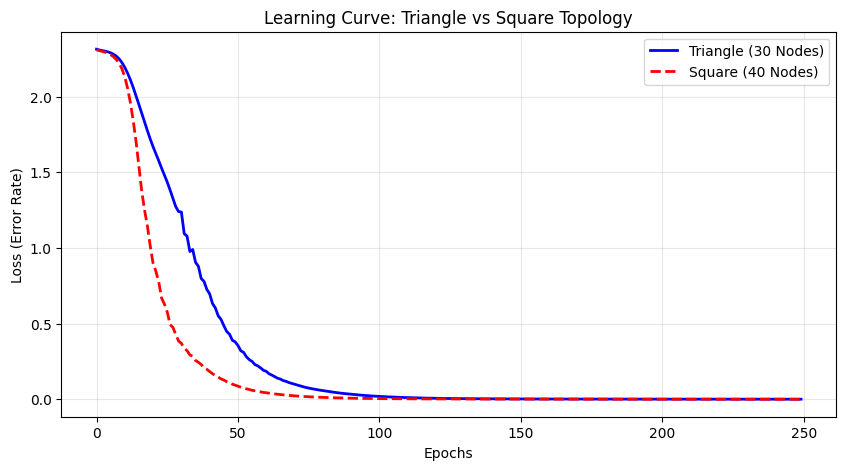

In [23]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. بارگذاری دیتاست تصاویر (ارقام دست‌نویس 8x8)
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری مثلث (۳۰ نورون - ۳ ضلع)
class PinballTriangle(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 30)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(30, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5): # ۵ برخورد باز شده
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۳. معماری مربع (۴۰ نورون - ۴ ضلع)
class PinballSquare(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 40)
        self.core = nn.Linear(40, 40)
        mask = torch.ones(40, 40)
        # ماسک کردن ۴ ضلع مساوی
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        mask[30:40, 30:40] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(40, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5): # ۵ برخورد باز شده
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۴. تنظیمات آموزش
epochs = 250
model_tri = PinballTriangle()
model_sq = PinballSquare()

opt_tri = optim.Adam(model_tri.parameters(), lr=0.005)
opt_sq = optim.Adam(model_sq.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

history_tri = []
history_sq = []

# ۵. حلقه آموزش همزمان
print("در حال نبرد مثلث و مربع... لطفاً صبر کنید.\n")
for epoch in range(epochs):
    # آموزش مثلث
    opt_tri.zero_grad()
    loss_t = criterion(model_tri(X_train), y_train)
    loss_t.backward()
    opt_tri.step()
    history_tri.append(loss_t.item())
    
    # آموزش مربع
    opt_sq.zero_grad()
    loss_s = criterion(model_sq(X_train), y_train)
    loss_s.backward()
    opt_sq.step()
    history_sq.append(loss_s.item())

# ارزیابی نهایی
with torch.no_grad():
    acc_tri = (model_tri(X_test).argmax(1) == y_test).float().mean().item() * 100
    acc_sq = (model_sq(X_test).argmax(1) == y_test).float().mean().item() * 100

print(f"دقت نهایی مثلث (30 نورون): {acc_tri:.2f}%")
print(f"دقت نهایی مربع (40 نورون): {acc_sq:.2f}%")

# ۶. رسم نمودار Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(history_tri, label=f'Triangle (30 Nodes)', color='blue', linewidth=2)
plt.plot(history_sq, label=f'Square (40 Nodes)', color='red', linewidth=2, linestyle='--')
plt.title('Learning Curve: Triangle vs Square Topology')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 32 neurons (768 connections)

در حال آموزش مثلث ۳۰ نورونی...
در حال آموزش مربع ۳۲ نورونی...

معیار سنجش           | مثلث (۳۰ نورون) | مربع (۳۲ نورون)
اتصالات فعال (مجاز)  | 600             | 768
دقت نهایی تست        | 96.11%          | 95.56%
زمان آموزش           | 0.5473 ثانیه    | 0.4750 ثانیه
زمان استنتاج         | 3.2310 میلی‌ثانیه | 0.8078 میلی‌ثانیه


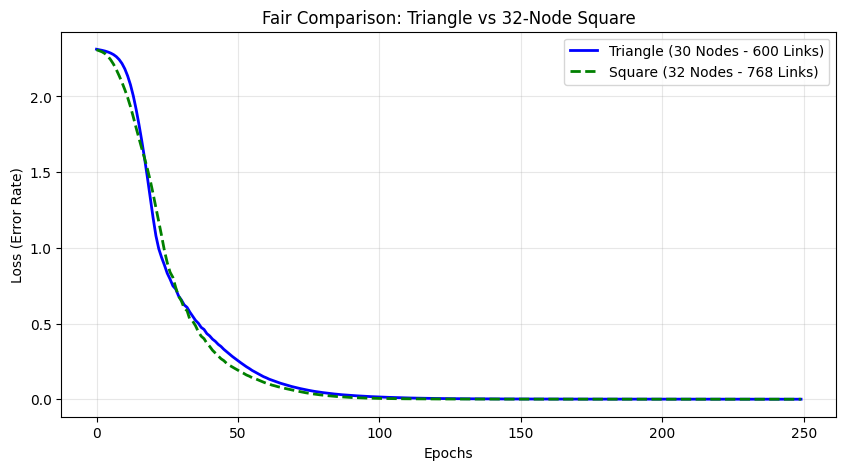

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. آماده‌سازی دیتا
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری مثلث (۳۰ نورون - ۳ ضلع ۱۰ تایی)
class PinballTriangle(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 30)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(30, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5):
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۳. معماری عادلانه مربع (۳۲ نورون - ۴ ضلع ۸ تایی)
class PinballSquare32(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 32)
        self.core = nn.Linear(32, 32)
        
        mask = torch.ones(32, 32)
        # ماسک کردن ۴ ضلع ۸ تایی
        mask[0:8, 0:8] = 0
        mask[8:16, 8:16] = 0
        mask[16:24, 16:24] = 0
        mask[24:32, 24:32] = 0
        self.register_buffer('mask', mask)
        
        self.exit = nn.Linear(32, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5):
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۴. تنظیمات و متغیرهای زمان‌سنجی
epochs = 250
model_tri = PinballTriangle()
model_sq32 = PinballSquare32()

opt_tri = optim.Adam(model_tri.parameters(), lr=0.005)
opt_sq32 = optim.Adam(model_sq32.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

history_tri = []
history_sq32 = []

# --- آموزش و زمان‌بندی مثلث ---
print("در حال آموزش مثلث ۳۰ نورونی...")
start_time = time.time()
for epoch in range(epochs):
    opt_tri.zero_grad()
    loss_t = criterion(model_tri(X_train), y_train)
    loss_t.backward()
    opt_tri.step()
    history_tri.append(loss_t.item())
time_tri_train = time.time() - start_time

# --- آموزش و زمان‌بندی مربع ۳۲ نورونی ---
print("در حال آموزش مربع ۳۲ نورونی...")
start_time = time.time()
for epoch in range(epochs):
    opt_sq32.zero_grad()
    loss_s = criterion(model_sq32(X_train), y_train)
    loss_s.backward()
    opt_sq32.step()
    history_sq32.append(loss_s.item())
time_sq32_train = time.time() - start_time

# --- ارزیابی سرعت پاسخ‌دهی (Inference Time) ---
start_time = time.time()
with torch.no_grad():
    acc_tri = (model_tri(X_test).argmax(1) == y_test).float().mean().item() * 100
time_tri_inf = (time.time() - start_time) * 1000

start_time = time.time()
with torch.no_grad():
    acc_sq32 = (model_sq32(X_test).argmax(1) == y_test).float().mean().item() * 100
time_sq32_inf = (time.time() - start_time) * 1000

# ۵. نمایش نتایج مقایسه عادلانه
print("\n" + "="*55)
print(f"{'معیار سنجش':<20} | {'مثلث (۳۰ نورون)':<15} | {'مربع (۳۲ نورون)':<15}")
print("="*55)
print(f"{'اتصالات فعال (مجاز)':<20} | 600{'':<12} | 768")
print(f"{'دقت نهایی تست':<20} | {acc_tri:.2f}%{'':<9} | {acc_sq32:.2f}%")
print(f"{'زمان آموزش':<20} | {time_tri_train:.4f} ثانیه{'':<3} | {time_sq32_train:.4f} ثانیه")
print(f"{'زمان استنتاج':<20} | {time_tri_inf:.4f} میلی‌ثانیه | {time_sq32_inf:.4f} میلی‌ثانیه")
print("="*55)

# ۶. رسم نمودار جدید
plt.figure(figsize=(10, 5))
plt.plot(history_tri, label=f'Triangle (30 Nodes - 600 Links)', color='blue', linewidth=2)
plt.plot(history_sq32, label=f'Square (32 Nodes - 768 Links)', color='green', linewidth=2, linestyle='--')
plt.title('Fair Comparison: Triangle vs 32-Node Square')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch

# استخراج ماتریس‌ها از مدل مثلث آموزش‌دیده (model_tri)
weights_matrix = model_tri.core.weight.data
mask_matrix = model_tri.mask
biases_array = model_tri.core.bias.data

# ایجاد فایل هدر با پشتیبانی از حروف فارسی (UTF-8)
with open("pinball_triangle_weights.h", "w", encoding="utf-8") as f:
    f.write("// این فایل توسط اسکریپت پایتون تولید شده است\n")
    f.write("// معماری: شبکه پینبال مثلثی (۳۰ نورون، ۶۰۰ اتصال مجاز)\n")
    f.write("#ifndef PINBALL_TRIANGLE_WEIGHTS_H\n#define PINBALL_TRIANGLE_WEIGHTS_H\n\n")
    
    # ۱. استخراج ایندکس‌ها (آدرس نورون‌های مجاز)
    # کلمه const این آرایه را مستقیماً به حافظه Flash میکروکنترلر می‌برد
    f.write("const int target_indices[30][20] = {\n")
    for i in range(30):
        # پیدا کردن ۲۰ اتصالی که ماسک آن‌ها ۱ است
        valid_indices = torch.nonzero(mask_matrix[i]).squeeze().tolist()
        f.write("    {" + ", ".join(map(str, valid_indices)) + "},\n")
    f.write("};\n\n")

    # ۲. استخراج مقادیر وزن‌های طلایی
    f.write("const float weights[30][20] = {\n")
    for i in range(30):
        valid_indices = torch.nonzero(mask_matrix[i]).squeeze()
        valid_weights = weights_matrix[i][valid_indices].tolist()
        # ذخیره با ۶ رقم اعشار برای دقت بالا در سخت‌افزار
        f.write("    {" + ", ".join([f"{w:.6f}" for w in valid_weights]) + "},\n")
    f.write("};\n\n")

    # ۳. استخراج بایاس‌ها
    f.write("const float biases[30] = {\n")
    biases_list = biases_array.tolist()
    f.write("    " + ", ".join([f"{b:.6f}" for b in biases_list]) + "\n")
    f.write("};\n\n")

    f.write("#endif // PINBALL_TRIANGLE_WEIGHTS_H\n")

print("فایل pinball_triangle_weights.h با موفقیت ساخته شد و وزن‌های طلایی در آن ذخیره شدند!")

## Hexagon 4 on each side (576 connections)

در حال آموزش مثلث ۳۰ نورونی...
در حال آموزش ۶ ضلعی ۲۴ نورونی...

معیار سنجش           | مثلث (۳۰ نورون) | ۶ ضلعی (۲۴ نورون)
اتصالات فعال (مجاز)  | 600             | 480
دقت نهایی تست        | 93.06%          | 94.17%
زمان آموزش           | 0.5526 ثانیه    | 0.5113 ثانیه
زمان استنتاج         | 0.6225 میلی‌ثانیه | 0.3514 میلی‌ثانیه


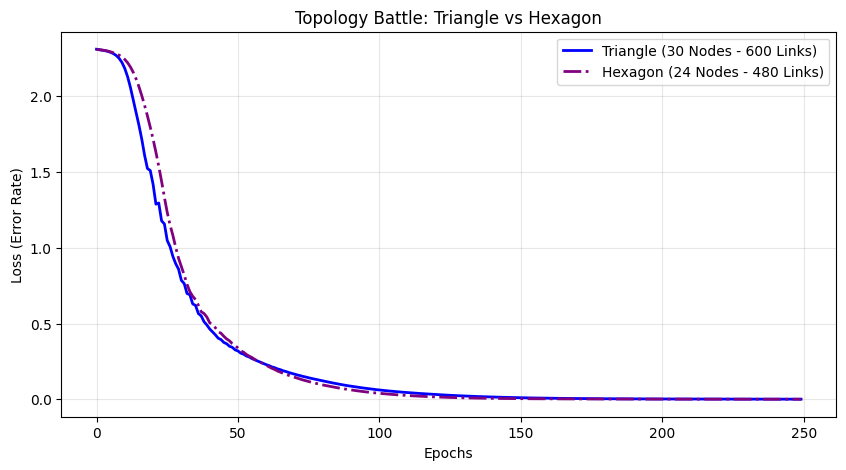

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. آماده‌سازی دیتا
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری مثلث طلایی (۳۰ نورون - ۶۰۰ اتصال)
class PinballTriangle(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 30)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0
        mask[10:20, 10:20] = 0
        mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(30, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5):
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۳. معماری ۶ ضلعی (۲۴ نورون - ۴۸۰ اتصال)
class PinballHexagon(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 24)
        self.core = nn.Linear(24, 24)
        
        # ساخت ماسک ۶ ضلعی
        mask = torch.ones(24, 24)
        for i in range(6):
            # مسدود کردن اتصالات روی هر ضلع (بلوک‌های ۴ در ۴)
            mask[i*4:(i+1)*4, i*4:(i+1)*4] = 0
            
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(24, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        b = self.core.bias
        for _ in range(5):
            out = torch.relu(F.linear(out, mw, b))
        return self.exit(out)

# ۴. تنظیمات رقابت
epochs = 250
model_tri = PinballTriangle()
model_hex = PinballHexagon()

opt_tri = optim.Adam(model_tri.parameters(), lr=0.005)
opt_hex = optim.Adam(model_hex.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

history_tri = []
history_hex = []

# --- زمان‌بندی و آموزش مثلث ---
print("در حال آموزش مثلث ۳۰ نورونی...")
start_time = time.time()
for epoch in range(epochs):
    opt_tri.zero_grad()
    loss_t = criterion(model_tri(X_train), y_train)
    loss_t.backward()
    opt_tri.step()
    history_tri.append(loss_t.item())
time_tri_train = time.time() - start_time

# --- زمان‌بندی و آموزش ۶ ضلعی ---
print("در حال آموزش ۶ ضلعی ۲۴ نورونی...")
start_time = time.time()
for epoch in range(epochs):
    opt_hex.zero_grad()
    loss_h = criterion(model_hex(X_train), y_train)
    loss_h.backward()
    opt_hex.step()
    history_hex.append(loss_h.item())
time_hex_train = time.time() - start_time

# --- ارزیابی سرعت پاسخ‌دهی (Inference) ---
start_time = time.time()
with torch.no_grad():
    acc_tri = (model_tri(X_test).argmax(1) == y_test).float().mean().item() * 100
time_tri_inf = (time.time() - start_time) * 1000

start_time = time.time()
with torch.no_grad():
    acc_hex = (model_hex(X_test).argmax(1) == y_test).float().mean().item() * 100
time_hex_inf = (time.time() - start_time) * 1000

# ۵. نمایش نتایج مقایسه
print("\n" + "="*55)
print(f"{'معیار سنجش':<20} | {'مثلث (۳۰ نورون)':<15} | {'۶ ضلعی (۲۴ نورون)':<15}")
print("="*55)
print(f"{'اتصالات فعال (مجاز)':<20} | 600{'':<12} | 480")
print(f"{'دقت نهایی تست':<20} | {acc_tri:.2f}%{'':<9} | {acc_hex:.2f}%")
print(f"{'زمان آموزش':<20} | {time_tri_train:.4f} ثانیه{'':<3} | {time_hex_train:.4f} ثانیه")
print(f"{'زمان استنتاج':<20} | {time_tri_inf:.4f} میلی‌ثانیه | {time_hex_inf:.4f} میلی‌ثانیه")
print("="*55)

# ۶. رسم نمودار Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(history_tri, label='Triangle (30 Nodes - 600 Links)', color='blue', linewidth=2)
plt.plot(history_hex, label='Hexagon (24 Nodes - 480 Links)', color='purple', linewidth=2, linestyle='-.')
plt.title('Topology Battle: Triangle vs Hexagon')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Validation with K-Fold

In [2]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold

# ۱. بارگذاری کل دیتاست
digits = load_digits()
X_np = digits.data
y_np = digits.target

X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.long)

# ۲. معماری ۶ ضلعی (۲۴ نورون - ۴۸۰ اتصال مجاز)
class PinballHexagon(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.entry = nn.Linear(input_dim, 24)
        self.core = nn.Linear(24, 24)
        
        # ساخت ماسک ۶ ضلعی
        mask = torch.ones(24, 24)
        for i in range(6):
            mask[i*4:(i+1)*4, i*4:(i+1)*4] = 0
            
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(24, num_classes)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        masked_weight = self.core.weight * self.mask
        bias = self.core.bias
        
        # ۵ برخورد باز شده (Unrolled)
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        out = torch.relu(F.linear(out, masked_weight, bias))
        
        return self.exit(out)

# ۳. تنظیمات Stratified K-Fold
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_accuracies = []
epochs = 200

print(f"شروع ارزیابی قطعی ۶ ضلعی با {k_folds}-Fold Cross-Validation...\n")
start_time = time.time()

# ۴. حلقه ارزیابی تکه‌ها
for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
    X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

    # ساخت مدل تازه برای هر تکه
    model = PinballHexagon()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        predictions = model(X_test)
        accuracy = (predictions.argmax(1) == y_test).float().mean().item() * 100
        fold_accuracies.append(accuracy)

    print(f"پایان مرحله {fold+1} | دقت روی دیتای تست: {accuracy:.2f}%")

# ۵. گزارش آماری نهایی ۶ ضلعی
total_time = time.time() - start_time
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\n" + "="*45)
print("             نتایج نهایی ۶ ضلعی")
print("="*45)
print(f"میانگین دقت کل (Mean Accuracy) : {mean_acc:.2f}%")
print(f"میزان نوسان (Standard Dev)     : ±{std_acc:.2f}%")
print(f"زمان کل اجرای تست              : {total_time:.2f} ثانیه")
print("="*45)

شروع ارزیابی قطعی ۶ ضلعی با 5-Fold Cross-Validation...

پایان مرحله 1 | دقت روی دیتای تست: 94.72%
پایان مرحله 2 | دقت روی دیتای تست: 96.94%
پایان مرحله 3 | دقت روی دیتای تست: 96.10%
پایان مرحله 4 | دقت روی دیتای تست: 94.71%
پایان مرحله 5 | دقت روی دیتای تست: 94.15%

             نتایج نهایی ۶ ضلعی
میانگین دقت کل (Mean Accuracy) : 95.32%
میزان نوسان (Standard Dev)     : ±1.03%
زمان کل اجرای تست              : 2.08 ثانیه


## Tower

در حال آموزش مثلث کلاسیک...
در حال آموزش برج ۴ طبقه ساعت‌شنی...

معیار سنجش           | مثلث کلاسیک     | برج ۴ طبقه     
دقت نهایی تست        | 96.39%          | 83.89%
زمان آموزش           | 0.6153 ثانیه    | 1.0482 ثانیه
زمان استنتاج         | 0.7496 ms      | 0.6695 ms


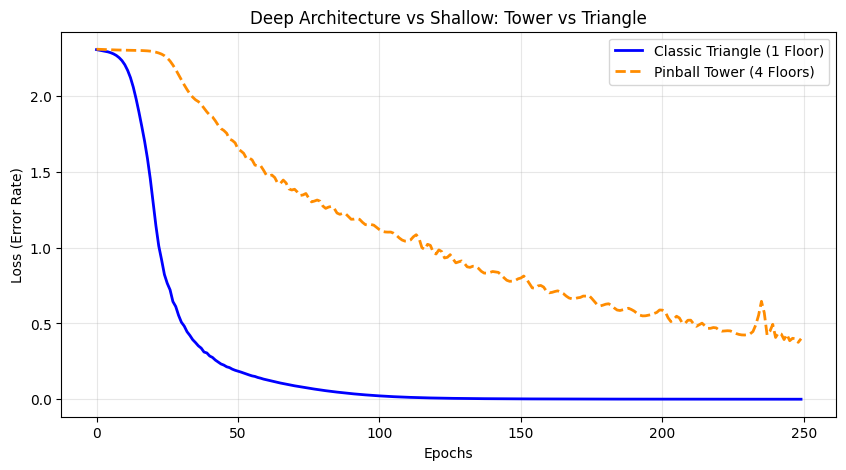

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. آماده‌سازی دیتاست
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# ۲. معماری مثلث تک‌لایه (به عنوان معیار مقایسه)
class PinballTriangle(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 30)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0; mask[10:20, 10:20] = 0; mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(30, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        for _ in range(5): # ۵ برخورد در تک‌لایه
            out = torch.relu(F.linear(out, mw, self.core.bias))
        return self.exit(out)

# ۳. معماری برج پینبال (ساعت‌شنی با ۴ طبقه)
class PinballTower(nn.Module):
    def __init__(self):
        super().__init__()
        # طبقه همکف: مثلث ۳۰ نورون
        self.dense0 = nn.Linear(64, 30)
        self.core0 = nn.Linear(30, 30)
        m0 = torch.ones(30, 30)
        m0[0:10,0:10]=0; m0[10:20,10:20]=0; m0[20:30,20:30]=0
        self.register_buffer('mask0', m0)

        # طبقه اول: ۶ ضلعی ۲۴ نورون
        self.dense1 = nn.Linear(30, 24)
        self.core1 = nn.Linear(24, 24)
        m1 = torch.ones(24, 24)
        for i in range(6): m1[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask1', m1)

        # طبقه دوم: مثلث ۱۵ نورون (گلوگاه اصلی - ۳ ضلع ۵ تایی)
        self.dense2 = nn.Linear(24, 15)
        self.core2 = nn.Linear(15, 15)
        m2 = torch.ones(15, 15)
        m2[0:5,0:5]=0; m2[5:10,5:10]=0; m2[10:15,10:15]=0
        self.register_buffer('mask2', m2)

        # طبقه سوم: ۶ ضلعی ۲۴ نورون
        self.dense3 = nn.Linear(15, 24)
        self.core3 = nn.Linear(24, 24)
        m3 = torch.ones(24, 24)
        for i in range(6): m3[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask3', m3)

        # سقف: خروجی
        self.exit = nn.Linear(24, 10)

    def forward(self, x):
        # ورود و پینبال در طبقه همکف
        out = torch.relu(self.dense0(x))
        mw0 = self.core0.weight * self.mask0
        for _ in range(2): out = torch.relu(F.linear(out, mw0, self.core0.bias))

        # صعود و پینبال در طبقه اول
        out = torch.relu(self.dense1(out))
        mw1 = self.core1.weight * self.mask1
        for _ in range(2): out = torch.relu(F.linear(out, mw1, self.core1.bias))

        # صعود به گلوگاه طبقه دوم
        out = torch.relu(self.dense2(out))
        mw2 = self.core2.weight * self.mask2
        for _ in range(2): out = torch.relu(F.linear(out, mw2, self.core2.bias))

        # صعود و بازسازی در طبقه سوم
        out = torch.relu(self.dense3(out))
        mw3 = self.core3.weight * self.mask3
        for _ in range(2): out = torch.relu(F.linear(out, mw3, self.core3.bias))

        return self.exit(out)

# ۴. تنظیمات رقابت
epochs = 250
model_base = PinballTriangle()
model_tower = PinballTower()

# چون برج عمیق‌تر است، لرنینگ‌ریت را کمی کمتر می‌کنیم تا پایدار بماند
opt_base = optim.Adam(model_base.parameters(), lr=0.005)
opt_tower = optim.Adam(model_tower.parameters(), lr=0.003) 
criterion = nn.CrossEntropyLoss()

history_base = []
history_tower = []

# --- آموزش مثلث تک‌لایه ---
print("در حال آموزش مثلث کلاسیک...")
start_time = time.time()
for epoch in range(epochs):
    opt_base.zero_grad()
    loss = criterion(model_base(X_train), y_train)
    loss.backward()
    opt_base.step()
    history_base.append(loss.item())
time_base_train = time.time() - start_time

# --- آموزش برج ۴ طبقه ---
print("در حال آموزش برج ۴ طبقه ساعت‌شنی...")
start_time = time.time()
for epoch in range(epochs):
    opt_tower.zero_grad()
    loss = criterion(model_tower(X_train), y_train)
    loss.backward()
    opt_tower.step()
    history_tower.append(loss.item())
time_tower_train = time.time() - start_time

# --- ارزیابی نهایی ---
start_time = time.time()
with torch.no_grad():
    acc_base = (model_base(X_test).argmax(1) == y_test).float().mean().item() * 100
time_base_inf = (time.time() - start_time) * 1000

start_time = time.time()
with torch.no_grad():
    acc_tower = (model_tower(X_test).argmax(1) == y_test).float().mean().item() * 100
time_tower_inf = (time.time() - start_time) * 1000

# ۵. چاپ نتایج
print("\n" + "="*60)
print(f"{'معیار سنجش':<20} | {'مثلث کلاسیک':<15} | {'برج ۴ طبقه':<15}")
print("="*60)
print(f"{'دقت نهایی تست':<20} | {acc_base:.2f}%{'':<9} | {acc_tower:.2f}%")
print(f"{'زمان آموزش':<20} | {time_base_train:.4f} ثانیه{'':<3} | {time_tower_train:.4f} ثانیه")
print(f"{'زمان استنتاج':<20} | {time_base_inf:.4f} ms{'':<5} | {time_tower_inf:.4f} ms")
print("="*60)

# ۶. رسم نمودار Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(history_base, label='Classic Triangle (1 Floor)', color='blue', linewidth=2)
plt.plot(history_tower, label='Pinball Tower (4 Floors)', color='darkorange', linewidth=2, linestyle='--')
plt.title('Deep Architecture vs Shallow: Tower vs Triangle')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

شروع مسابقه ۴ جانبه! لطفاً چند ثانیه صبر کنید...

مدل (معماری)                   | دقت تست    | زمان آموزش      | زمان استنتاج
۱. مثلث کلاسیک (تک‌لایه)       | 95.56%     | 0.7108 ثانیه | 0.6578 ms
۲. برج پینبال (ساده و کُند)    | 67.78%     | 1.0737 ثانیه | 0.6299 ms
۳. برج پینبال + میان‌بر (ResNet) | 95.83%     | 1.1406 ثانیه | 0.6611 ms
۴. شبکه استاندارد (MLP متراکم) | 95.56%     | 0.5057 ثانیه | 0.2968 ms


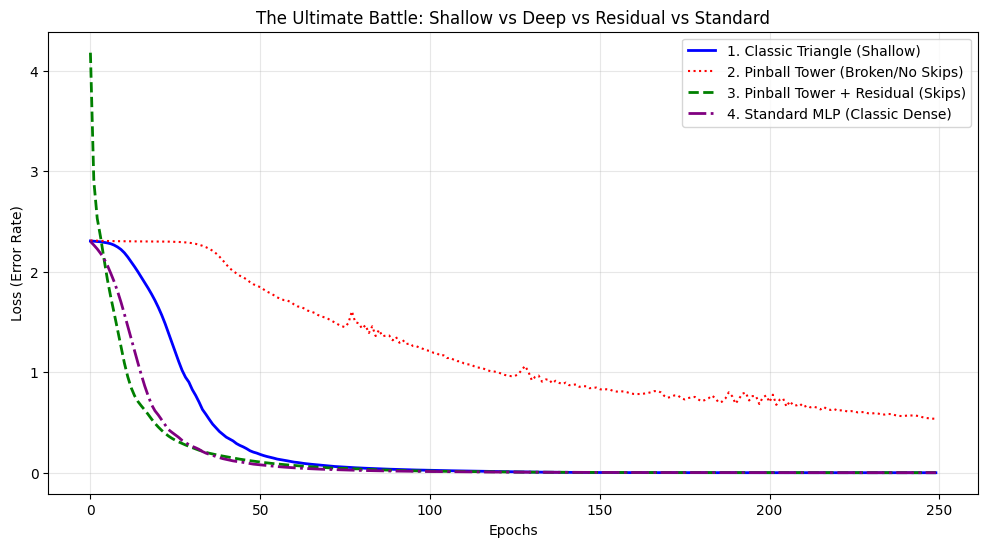

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ۱. آماده‌سازی دیتاست
digits = load_digits()
X_np, y_np = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# =======================================================
# مدل ۱: مثلث تک‌لایه (سریع و پایدار - به عنوان خط کش)
# =======================================================
class PinballTriangle(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Linear(64, 30)
        self.core = nn.Linear(30, 30)
        mask = torch.ones(30, 30)
        mask[0:10, 0:10] = 0; mask[10:20, 10:20] = 0; mask[20:30, 20:30] = 0
        self.register_buffer('mask', mask)
        self.exit = nn.Linear(30, 10)

    def forward(self, x):
        out = torch.relu(self.entry(x))
        mw = self.core.weight * self.mask
        for _ in range(5):
            out = torch.relu(F.linear(out, mw, self.core.bias))
        return self.exit(out)

# =======================================================
# مدل ۲: برج پینبال (ساعت‌شنی با ۴ طبقه - بدون میان‌بر)
# =======================================================
class PinballTower(nn.Module):
    def __init__(self):
        super().__init__()
        # طبقه ۰
        self.dense0 = nn.Linear(64, 30); self.core0 = nn.Linear(30, 30)
        m0 = torch.ones(30, 30); m0[0:10,0:10]=0; m0[10:20,10:20]=0; m0[20:30,20:30]=0
        self.register_buffer('mask0', m0)
        # طبقه ۱
        self.dense1 = nn.Linear(30, 24); self.core1 = nn.Linear(24, 24)
        m1 = torch.ones(24, 24)
        for i in range(6): m1[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask1', m1)
        # طبقه ۲ (گلوگاه)
        self.dense2 = nn.Linear(24, 15); self.core2 = nn.Linear(15, 15)
        m2 = torch.ones(15, 15); m2[0:5,0:5]=0; m2[5:10,5:10]=0; m2[10:15,10:15]=0
        self.register_buffer('mask2', m2)
        # طبقه ۳
        self.dense3 = nn.Linear(15, 24); self.core3 = nn.Linear(24, 24)
        m3 = torch.ones(24, 24)
        for i in range(6): m3[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask3', m3)
        # سقف
        self.exit = nn.Linear(24, 10)

    def forward(self, x):
        out = torch.relu(self.dense0(x))
        mw0 = self.core0.weight * self.mask0
        for _ in range(2): out = torch.relu(F.linear(out, mw0, self.core0.bias))

        out = torch.relu(self.dense1(out))
        mw1 = self.core1.weight * self.mask1
        for _ in range(2): out = torch.relu(F.linear(out, mw1, self.core1.bias))

        out = torch.relu(self.dense2(out))
        mw2 = self.core2.weight * self.mask2
        for _ in range(2): out = torch.relu(F.linear(out, mw2, self.core2.bias))

        out = torch.relu(self.dense3(out))
        mw3 = self.core3.weight * self.mask3
        for _ in range(2): out = torch.relu(F.linear(out, mw3, self.core3.bias))

        return self.exit(out)

# =======================================================
# مدل ۳: برج پینبال + اتصالات میان‌بر (معجزه ResNet)
# =======================================================
class PinballTowerResidual(nn.Module):
    def __init__(self):
        super().__init__()
        self.dense0 = nn.Linear(64, 30); self.core0 = nn.Linear(30, 30)
        m0 = torch.ones(30, 30); m0[0:10,0:10]=0; m0[10:20,10:20]=0; m0[20:30,20:30]=0
        self.register_buffer('mask0', m0)

        self.dense1 = nn.Linear(30, 24); self.core1 = nn.Linear(24, 24)
        m1 = torch.ones(24, 24)
        for i in range(6): m1[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask1', m1)

        self.dense2 = nn.Linear(24, 15); self.core2 = nn.Linear(15, 15)
        m2 = torch.ones(15, 15); m2[0:5,0:5]=0; m2[5:10,5:10]=0; m2[10:15,10:15]=0
        self.register_buffer('mask2', m2)

        self.dense3 = nn.Linear(15, 24); self.core3 = nn.Linear(24, 24)
        m3 = torch.ones(24, 24)
        for i in range(6): m3[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask3', m3)

        self.exit = nn.Linear(24, 10)
        
        # اتصال میان‌بر سراسری (سیم‌کشی از ورودی تا سقف)
        self.global_skip = nn.Linear(64, 24)

    def forward(self, x):
        global_identity = self.global_skip(x)
        
        # طبقه همکف
        out = torch.relu(self.dense0(x))
        identity = out  # ذخیره دیتای خام برای میان‌بر
        mw0 = self.core0.weight * self.mask0
        for _ in range(2): out = torch.relu(F.linear(out, mw0, self.core0.bias))
        out = out + identity # <--- میان‌بر محلی

        # طبقه اول
        out = torch.relu(self.dense1(out))
        identity = out
        mw1 = self.core1.weight * self.mask1
        for _ in range(2): out = torch.relu(F.linear(out, mw1, self.core1.bias))
        out = out + identity # <--- میان‌بر محلی

        # گلوگاه طبقه دوم
        out = torch.relu(self.dense2(out))
        identity = out
        mw2 = self.core2.weight * self.mask2
        for _ in range(2): out = torch.relu(F.linear(out, mw2, self.core2.bias))
        out = out + identity # <--- میان‌بر محلی

        # طبقه سوم
        out = torch.relu(self.dense3(out))
        identity = out
        mw3 = self.core3.weight * self.mask3
        for _ in range(2): out = torch.relu(F.linear(out, mw3, self.core3.bias))
        out = out + identity # <--- میان‌بر محلی
        
        # اضافه کردن میان‌بر سراسری قبل از طبقه‌بندی نهایی
        out = out + global_identity

        return self.exit(out)

# =======================================================
# مدل ۴: شبکه کلاسیک کاملاً متصل (بدون ماسک و پینبال)
# =======================================================
class StandardMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # دقیقاً همان شکل ساعت‌شنی، اما کاملاً متصل
        self.net = nn.Sequential(
            nn.Linear(64, 30), nn.ReLU(),
            nn.Linear(30, 24), nn.ReLU(),
            nn.Linear(24, 15), nn.ReLU(),
            nn.Linear(15, 24), nn.ReLU(),
            nn.Linear(24, 10)
        )
    def forward(self, x):
        return self.net(x)

# =======================================================
# راه‌اندازی مسابقه
# =======================================================
epochs = 250
model_base = PinballTriangle()
model_tower = PinballTower()
model_res = PinballTowerResidual()
model_mlp = StandardMLP()

opt_base = optim.Adam(model_base.parameters(), lr=0.005)
opt_tower = optim.Adam(model_tower.parameters(), lr=0.003)
opt_res = optim.Adam(model_res.parameters(), lr=0.003)
opt_mlp = optim.Adam(model_mlp.parameters(), lr=0.005)

criterion = nn.CrossEntropyLoss()

history_base, history_tower, history_res, history_mlp = [], [], [], []

print("شروع مسابقه ۴ جانبه! لطفاً چند ثانیه صبر کنید...\n")

# تابع کمکی برای آموزش
def train_model(model, optimizer, history_list, name):
    start_time = time.time()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        history_list.append(loss.item())
    return time.time() - start_time

time_base_train = train_model(model_base, opt_base, history_base, "Triangle")
time_tower_train = train_model(model_tower, opt_tower, history_tower, "Tower")
time_res_train = train_model(model_res, opt_res, history_res, "Residual Tower")
time_mlp_train = train_model(model_mlp, opt_mlp, history_mlp, "Standard MLP")

# ارزیابی نهایی
def evaluate_model(model):
    start_time = time.time()
    with torch.no_grad():
        acc = (model(X_test).argmax(1) == y_test).float().mean().item() * 100
    return acc, (time.time() - start_time) * 1000

acc_base, time_base_inf = evaluate_model(model_base)
acc_tower, time_tower_inf = evaluate_model(model_tower)
acc_res, time_res_inf = evaluate_model(model_res)
acc_mlp, time_mlp_inf = evaluate_model(model_mlp)

# =======================================================
# چاپ نتایج و رسم نمودار
# =======================================================
print("="*85)
print(f"{'مدل (معماری)':<30} | {'دقت تست':<10} | {'زمان آموزش':<15} | {'زمان استنتاج'}")
print("="*85)
print(f"{'۱. مثلث کلاسیک (تک‌لایه)':<30} | {acc_base:.2f}%{'':<4} | {time_base_train:.4f} ثانیه | {time_base_inf:.4f} ms")
print(f"{'۲. برج پینبال (ساده و کُند)':<30} | {acc_tower:.2f}%{'':<4} | {time_tower_train:.4f} ثانیه | {time_tower_inf:.4f} ms")
print(f"{'۳. برج پینبال + میان‌بر (ResNet)':<28} | {acc_res:.2f}%{'':<4} | {time_res_train:.4f} ثانیه | {time_res_inf:.4f} ms")
print(f"{'۴. شبکه استاندارد (MLP متراکم)':<28} | {acc_mlp:.2f}%{'':<4} | {time_mlp_train:.4f} ثانیه | {time_mlp_inf:.4f} ms")
print("="*85)

plt.figure(figsize=(12, 6))
plt.plot(history_base, label='1. Classic Triangle (Shallow)', color='blue', linewidth=2)
plt.plot(history_tower, label='2. Pinball Tower (Broken/No Skips)', color='red', linewidth=1.5, linestyle=':')
plt.plot(history_res, label='3. Pinball Tower + Residual (Skips)', color='green', linewidth=2, linestyle='--')
plt.plot(history_mlp, label='4. Standard MLP (Classic Dense)', color='purple', linewidth=2, linestyle='-.')

plt.title('The Ultimate Battle: Shallow vs Deep vs Residual vs Standard')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## testing tower on image dataset

در حال دانلود و بارگذاری Fashion-MNIST...


100%|██████████| 26.4M/26.4M [00:10<00:00, 2.46MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 842kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 968kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.14MB/s]


آموزش روی پردازنده: cpu

شروع آموزش برج پینبال روی تصاویر لباس و کفش...
ایپاک 1/15 | خطای آموزش: 0.5266
ایپاک 2/15 | خطای آموزش: 0.4302
ایپاک 3/15 | خطای آموزش: 0.3909
ایپاک 4/15 | خطای آموزش: 0.3674
ایپاک 5/15 | خطای آموزش: 0.3510
ایپاک 6/15 | خطای آموزش: 0.3396
ایپاک 7/15 | خطای آموزش: 0.3272
ایپاک 8/15 | خطای آموزش: 0.3207
ایپاک 9/15 | خطای آموزش: 0.3135
ایپاک 10/15 | خطای آموزش: 0.3065
ایپاک 11/15 | خطای آموزش: 0.3012
ایپاک 12/15 | خطای آموزش: 0.2960
ایپاک 13/15 | خطای آموزش: 0.2907
ایپاک 14/15 | خطای آموزش: 0.2878
ایپاک 15/15 | خطای آموزش: 0.2842
دقت نهایی برج پینبال روی ۱۰ هزار تصویر تست: 86.47%


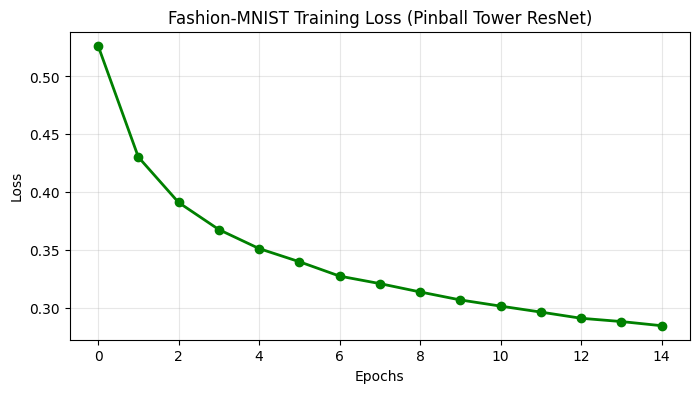

In [2]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ۱. دانلود و آماده‌سازی دیتاست واقعی (Fashion-MNIST)
print("در حال دانلود و بارگذاری Fashion-MNIST...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # نرمال‌سازی پیکسل‌ها بین -1 و 1
])

# دیتای آموزش (۶۰ هزار عکس)
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# استفاده از DataLoader برای دسته‌بندی ۶۴ تایی (Mini-batch)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# دیتای تست (۱۰ هزار عکس)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# ۲. بروزرسانی برج پینبال میان‌بر دار برای ورودی بزرگتر (۷۸۴ پیکسل)
class PinballTowerResidual_Fashion(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        # ورودی حالا 784 پیکسل است (28x28)
        self.dense0 = nn.Linear(input_dim, 30); self.core0 = nn.Linear(30, 30)
        m0 = torch.ones(30, 30); m0[0:10,0:10]=0; m0[10:20,10:20]=0; m0[20:30,20:30]=0
        self.register_buffer('mask0', m0)

        self.dense1 = nn.Linear(30, 24); self.core1 = nn.Linear(24, 24)
        m1 = torch.ones(24, 24)
        for i in range(6): m1[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask1', m1)

        self.dense2 = nn.Linear(24, 15); self.core2 = nn.Linear(15, 15)
        m2 = torch.ones(15, 15); m2[0:5,0:5]=0; m2[5:10,5:10]=0; m2[10:15,10:15]=0
        self.register_buffer('mask2', m2)

        self.dense3 = nn.Linear(15, 24); self.core3 = nn.Linear(24, 24)
        m3 = torch.ones(24, 24)
        for i in range(6): m3[i*4:(i+1)*4, i*4:(i+1)*4] = 0
        self.register_buffer('mask3', m3)

        self.exit = nn.Linear(24, num_classes)
        self.global_skip = nn.Linear(input_dim, 24)

    def forward(self, x):
        # Flatten کردن عکس‌های 28x28 به وکتور 784 تایی
        x = x.view(x.size(0), -1) 
        
        global_identity = self.global_skip(x)
        
        out = torch.relu(self.dense0(x))
        identity = out
        mw0 = self.core0.weight * self.mask0
        for _ in range(2): out = torch.relu(F.linear(out, mw0, self.core0.bias))
        out = out + identity

        out = torch.relu(self.dense1(out))
        identity = out
        mw1 = self.core1.weight * self.mask1
        for _ in range(2): out = torch.relu(F.linear(out, mw1, self.core1.bias))
        out = out + identity

        out = torch.relu(self.dense2(out))
        identity = out
        mw2 = self.core2.weight * self.mask2
        for _ in range(2): out = torch.relu(F.linear(out, mw2, self.core2.bias))
        out = out + identity

        out = torch.relu(self.dense3(out))
        identity = out
        mw3 = self.core3.weight * self.mask3
        for _ in range(2): out = torch.relu(F.linear(out, mw3, self.core3.bias))
        out = out + identity
        
        out = out + global_identity
        return self.exit(out)

# ۳. تنظیمات آموزش (روی دیتای بزرگ)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"آموزش روی پردازنده: {device}")

model = PinballTowerResidual_Fashion().to(device)
criterion = nn.CrossEntropyLoss()
# استفاده از AdamW برای وزن‌های منظم‌تر روی دیتای واقعی
optimizer = optim.AdamW(model.parameters(), lr=0.002)

epochs = 15 # روی دیتاست 60 هزار تایی، 15 ایپاک کافیست
history_loss = []

# ۴. حلقه آموزش با Mini-batch
print("\nشروع آموزش برج پینبال روی تصاویر لباس و کفش...")
for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    epoch_loss = running_loss / len(trainloader)
    history_loss.append(epoch_loss)
    print(f"ایپاک {epoch+1}/{epochs} | خطای آموزش: {epoch_loss:.4f}")

# ۵. ارزیابی نهایی روی ۱۰ هزار عکس جدید
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("="*50)
print(f"دقت نهایی برج پینبال روی ۱۰ هزار تصویر تست: {accuracy:.2f}%")
print("="*50)

# رسم نمودار خطا
plt.figure(figsize=(8, 4))
plt.plot(history_loss, color='green', linewidth=2, marker='o')
plt.title('Fashion-MNIST Training Loss (Pinball Tower ResNet)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()